In [1]:
#Importing the required
import numpy as np
import datasets
from datasets import load_dataset
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import seaborn as sns
#For Deep learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\midst\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [143]:
setwd = "D:/Sathish/AIML/Fianl Project/"

In [20]:
#Loading the Datasets
ds = load_dataset("Tobi-Bueck/customer-support-tickets")

In [21]:
pd.set_option("display.max_rows", None)   # show all rows
pd.set_option("display.max_columns", None) # show all columns
ds1 = pd.DataFrame(ds)

In [22]:
ds1.head(10)

,train
0,"{'subject': 'Wesentlicher Sicherheitsvorfall',..."
1,"{'subject': 'Account Disruption', 'body': 'Dea..."
2,{'subject': 'Query About Smart Home System Int...
3,{'subject': 'Inquiry Regarding Invoice Details...
4,{'subject': 'Question About Marketing Agency S...
5,"{'subject': 'Feature Query', 'body': 'Dear Cus..."
6,"{'subject': 'System Interruptions', 'body': 'D..."
7,{'subject': 'Connectivity Problems with Printe...
8,{'subject': 'Anfrage nach detaillierten Angabe...
9,{'subject': 'Anfrage zur Klärung der Auswirkun...


In [23]:
print(ds1['train'].iloc[0])

{'subject': 'Wesentlicher Sicherheitsvorfall', 'body': 'Sehr geehrtes Support-Team,\\n\\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\\n\\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eliminiert.', 'answer': 'Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie der ergriffenen ersten Maßnahmen. Wir erk

In [24]:
data = data['train'].apply(pd.Series)
data.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [51]:
data.to_csv("Data.csv",index=False)

In [39]:
data = pd.read_csv("Raw_Data.csv")

In [40]:
data.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,wesentlicher sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,account disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,query smart home system integration features,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,inquiry regarding invoice details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,question marketing agency software compatibility,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [41]:
data.iloc[101]['body']

"Dear Customer Support Team,\\n\\nI am reaching out to seek guidance on implementing vital upgrades to our infrastructure, which are crucial for advancing the company's data processing capabilities. The objectives include improving support for sophisticated data lakes, incorporating Python-based machine learning models, and deploying automated balancing engines across various divisions. These improvements aim to enhance real-time analytical functions, ESG (Environmental, Social, Governance) reporting, and automation of investment strategies.\\n\\nAt present, our infrastructure does not support scalability."

In [42]:
data.subject.value_counts()

subject
anfrage unterstützung                                       9
dienstleistungen datenanalyse                               8
enhancing security medical data hospital systems            8
inquiry data analytics services investment optimization     8
unterstützung datenanalyse                                  8
                                                           ..
issue regarding data encryption                             1
issue project upload                                        1
effiziente optimierung investitionsportfolios               1
inquiry in-depth details financial institution offerings    1
request issue explanation                                   1
Name: count, Length: 45317, dtype: int64

In [43]:
data['language'].value_counts()

language
de    33504
en    28261
Name: count, dtype: int64

In [44]:
""" 
def translate_to_en(text, lang):
    try:
        if lang == "de":
            return GoogleTranslator(source="de", target="en").translate(text)
        return text
    except Exception as e:
        print("Translation failed:", e)
        return text  # fallback: keep original
data['subject_en'] = [translate_to_en(subj, lang) for subj, lang in zip(data['subject'], data['language'])]
data['body'] = data.apply(lambda row: translate_to_en(row['body'],row['language']),axis=1)
data['answer'] = data.apply(lambda row: translate_to_en(row['answer'],row['language']),axis=1)
"""


' \ndef translate_to_en(text, lang):\n    try:\n        if lang == "de":\n            return GoogleTranslator(source="de", target="en").translate(text)\n        return text\n    except Exception as e:\n        print("Translation failed:", e)\n        return text  # fallback: keep original\ndata[\'subject_en\'] = [translate_to_en(subj, lang) for subj, lang in zip(data[\'subject\'], data[\'language\'])]\ndata[\'body\'] = data.apply(lambda row: translate_to_en(row[\'body\'],row[\'language\']),axis=1)\ndata[\'answer\'] = data.apply(lambda row: translate_to_en(row[\'answer\'],row[\'language\']),axis=1)\n'

In [45]:
data.drop_duplicates(inplace=True)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  object 
 1   body      61763 non-null  object 
 2   answer    48576 non-null  object 
 3   type      48587 non-null  object 
 4   queue     61765 non-null  object 
 5   priority  61765 non-null  object 
 6   language  61765 non-null  object 
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  object 
 9   tag_2     48528 non-null  object 
 10  tag_3     48356 non-null  object 
 11  tag_4     43990 non-null  object 
 12  tag_5     27636 non-null  object 
 13  tag_6     13225 non-null  object 
 14  tag_7     5968 non-null   object 
 15  tag_8     2472 non-null   object 
dtypes: float64(1), object(15)
memory usage: 7.5+ MB


In [47]:
for i in data.columns:
    print(i,":", (100*data[i].isnull().sum()/data.shape[0]))

subject : 8.579292479559621
body : 0.00323807981866753
answer : 21.35351736420303
type : 21.335707925200357
queue : 0.0
priority : 0.0
language : 0.0
version : 53.71650611187566
tag_1 : 21.335707925200357
tag_2 : 21.431231279851048
tag_3 : 21.709706144256455
tag_4 : 28.778434388407675
tag_5 : 55.25621306565207
tag_6 : 78.58819719906096
tag_7 : 90.3375698210961
tag_8 : 95.99773334412693


In [ ]:
#Data Preprocessing
def clean_text(text, lang):
    if not isinstance(text,str):
        return ""
    if lang == 'en':
        text = text.lower()
        text = re.sub("'","",text)
        text = re.sub(r'\s+',' ',text)
        text = re.sub(r'\n+',' ',text)
        tokens = word_tokenize(text,language='english')
        token = [i for i in tokens if i not in stopwords.words('english') and i not in string.punctuation]
        return " ".join(token)
    else:
        text = text.lower()
        text = re.sub("'","",text)
        text = re.sub(r'\s+',' ',text)
        text = re.sub(r'\n+',' ',text)
        tokens = word_tokenize(text,language='german')
        token = [i for i in tokens if i not in stopwords.words('german') and i not in string.punctuation] 
        return " ".join(token)
data['subject'] = data.apply(lambda row: clean_text(row['subject'],row['language']),axis=1)
data['body'] = data.apply(lambda row: clean_text(row['body'],row['language']),axis=1)
data['answer'] = data.apply(lambda row: clean_text(row['answer'],row['language']),axis=1)

In [50]:
data.iloc[1]['subject']

'account disruption'

In [51]:
data.to_csv("Clean_data.csv",index=False)

In [3]:
#Loading the cleaned datset
data = pd.read_csv("Clean_data.csv")

In [ ]:
keywords = ["refund", "login issue", "payment failed"]
sia = SentimentIntensityAnalyzer()
urgency_words = ["urgent","asap","immediately"]
def keyword_features(text):
    if not isinstance(text,str):
        return ""
    return {f"has_{kw}": (kw in text) for kw in keywords}
def urgency_features(text):
    if not isinstance(text,str):
        return ""
    return {f"has_{ug}":(ug in text) for ug in urgency_words}

In [5]:
def sentiment_score(text):
    if not isinstance(text,str):
        return ""
    scores =sia.polarity_scores(text)
    return {
        "pos":scores['pos'],
        "neg":scores['neg'],
        'neu':scores['neu'],
        'com':scores['compound']
    }

In [6]:
def extract_features(text):
    features = {}
    features.update(keyword_features(text))
    features.update(urgency_features(text))
    features.update(sentiment_score(text))
    return features

In [7]:
data_en = data[data['language'] == 'en']

In [8]:
data_en.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28261 entries, 1 to 61762
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   24622 non-null  object 
 1   body      28260 non-null  object 
 2   answer    28255 non-null  object 
 3   type      28261 non-null  object 
 4   queue     28261 non-null  object 
 5   priority  28261 non-null  object 
 6   language  28261 non-null  object 
 7   version   16338 non-null  float64
 8   tag_1     28261 non-null  object 
 9   tag_2     28245 non-null  object 
 10  tag_3     28148 non-null  object 
 11  tag_4     25677 non-null  object 
 12  tag_5     16301 non-null  object 
 13  tag_6     7908 non-null   object 
 14  tag_7     3699 non-null   object 
 15  tag_8     1608 non-null   object 
dtypes: float64(1), object(15)
memory usage: 3.7+ MB


In [9]:
data_en = data_en[~(data_en['body'].isnull())]

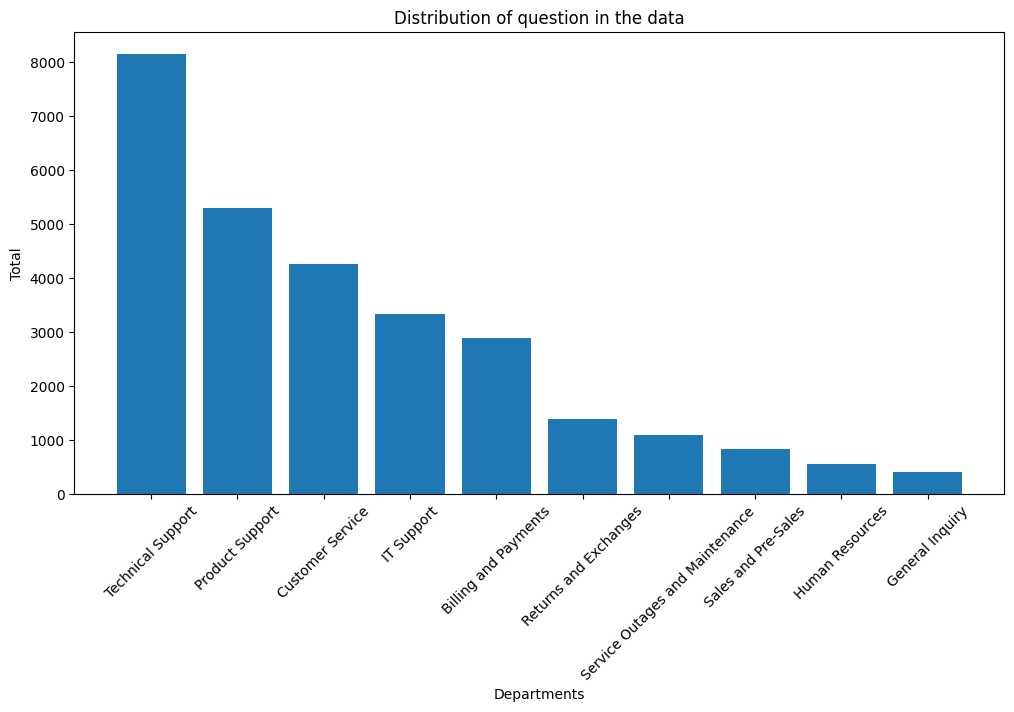

In [66]:
a = data_en['queue'].value_counts().reset_index()
a = a.sort_values(by='count',ascending=False)
plt.figure(figsize= (12,6))
plt.bar(a['queue'],a['count'])
plt.xticks(rotation = 45)
plt.ylabel("Total")
plt.xlabel("Departments")
plt.title("Distribution of question in the data")
plt.show()

In [10]:
features = data_en['body'].apply(extract_features)
features_df = features.apply(pd.Series)

In [11]:
features.shape

(28260,)

In [12]:
data1 = pd.concat([data_en,features_df],axis = 1)

In [13]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28260 entries, 1 to 61762
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subject             24621 non-null  object 
 1   body                28260 non-null  object 
 2   answer              28254 non-null  object 
 3   type                28260 non-null  object 
 4   queue               28260 non-null  object 
 5   priority            28260 non-null  object 
 6   language            28260 non-null  object 
 7   version             16338 non-null  float64
 8   tag_1               28260 non-null  object 
 9   tag_2               28244 non-null  object 
 10  tag_3               28147 non-null  object 
 11  tag_4               25676 non-null  object 
 12  tag_5               16300 non-null  object 
 13  tag_6               7907 non-null   object 
 14  tag_7               3699 non-null   object 
 15  tag_8               1608 non-null   object 
 16  has_refun

In [15]:
#data1[['has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately']] = data1[['has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately']].astype(bool)

In [16]:
data1[['body','has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately','pos','neg','neu','com']].info()
X = data1[['body','has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately','pos','neg','neu','com']]

<class 'pandas.core.frame.DataFrame'>
Index: 28260 entries, 1 to 61762
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   body                28260 non-null  object 
 1   has_refund          28260 non-null  bool   
 2   has_login issue     28260 non-null  bool   
 3   has_payment failed  28260 non-null  bool   
 4   has_urgent          28260 non-null  bool   
 5   has_asap            28260 non-null  bool   
 6   has_immediately     28260 non-null  bool   
 7   pos                 28260 non-null  float64
 8   neg                 28260 non-null  float64
 9   neu                 28260 non-null  float64
 10  com                 28260 non-null  float64
dtypes: bool(6), float64(4), object(1)
memory usage: 1.5+ MB


In [17]:
X.shape

(28260, 11)

In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28260 entries, 1 to 61762
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   body                28260 non-null  object 
 1   has_refund          28260 non-null  bool   
 2   has_login issue     28260 non-null  bool   
 3   has_payment failed  28260 non-null  bool   
 4   has_urgent          28260 non-null  bool   
 5   has_asap            28260 non-null  bool   
 6   has_immediately     28260 non-null  bool   
 7   pos                 28260 non-null  float64
 8   neg                 28260 non-null  float64
 9   neu                 28260 non-null  float64
 10  com                 28260 non-null  float64
dtypes: bool(6), float64(4), object(1)
memory usage: 1.5+ MB


In [19]:
le = LabelEncoder()
y = le.fit_transform(data1['queue'])

In [20]:
X_train, X_temp, y_train,y_temp = train_test_split(X,y,test_size=0.2,random_state=42)
X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

In [21]:
tf_body = TfidfVectorizer()
X_train_tfidf = tf_body.fit_transform(X_train['body'])
X_val_tfidf   = tf_body.transform(X_val['body'])
X_test_tfidf  = tf_body.transform(X_test['body'])


In [22]:
num_features = ['has_refund','has_login issue','has_payment failed','has_urgent','has_asap','has_immediately','pos','neg','neu','com']

X_train_num = X_train[num_features].astype(float).values
X_val_num   = X_val[num_features].astype(float).values
X_test_num  = X_test[num_features].astype(float).values

scaler = MinMaxScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num[:, -4:])
X_val_num_scaled   = scaler.transform(X_val_num[:, -4:])
X_test_num_scaled  = scaler.transform(X_test_num[:, -4:])

#Replace the scaled part to the orginal
X_train_num[:, -4:] = X_train_num_scaled
X_val_num[:, -4:]   = X_val_num_scaled
X_test_num[:, -4:]  = X_test_num_scaled

In [23]:
#Combine tfidf + numeric features
from scipy.sparse import hstack, csr_matrix
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_num)])
X_val_final   = hstack([X_val_tfidf,   csr_matrix(X_val_num)])
X_test_final  = hstack([X_test_tfidf,  csr_matrix(X_test_num)])

In [24]:
models = {"Logistic Regression": LogisticRegression(class_weight='balanced'),"GaussionNB":GaussianNB(),"SVM":LinearSVC(class_weight='balanced')}

In [25]:
from sklearn.metrics import precision_score,recall_score,accuracy_score,confusion_matrix,f1_score
results = {}
for name,model in models.items():
    if name == "GaussionNB":
        model.fit(X_train_final.toarray(),y_train)
        y_val_pred = model.predict(X_val_final.toarray())
    else:
        model.fit(X_train_final,y_train)
        y_val_pred = model.predict(X_val_final)
    results[name]={
        "Accuracy":accuracy_score(y_val,y_val_pred),
        "Precision":precision_score(y_val,y_val_pred,average="macro"),
        "Recall":recall_score(y_val,y_val_pred,average='macro'),
        "F1":f1_score(y_val,y_val_pred,average='macro')
    }

In [26]:
for name, metrics in results.items():
    print(f"\n{name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Logistic Regression
Accuracy: 0.4278
Precision: 0.3977
Recall: 0.5312
F1: 0.4252

GaussionNB
Accuracy: 0.2849
Precision: 0.3153
Recall: 0.4103
F1: 0.2832

SVM
Accuracy: 0.5223
Precision: 0.4860
Recall: 0.5884
F1: 0.5199


In [27]:
#Using the Sentence transformer for body variable
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L12-v2")
X_train_encode = model.encode(X_train['body'].tolist(),convert_to_numpy=True)
X_val_encode   = model.encode(X_val['body'].tolist(),convert_to_numpy=True)
X_test_encode  = model.encode(X_test['body'].tolist(),convert_to_numpy=True)

In [28]:
#"""No need of scaling is needed for sentence transformer as it is already normalised dense and also the reason why tfidf is fitted and transform is because it learns
# from the train dataset and it is fitted to the val and test """

In [29]:
#Combine encoded vector + numeric features
from scipy.sparse import hstack, csr_matrix
X_train_final = hstack([X_train_encode, csr_matrix(X_train_num)])
X_val_final   = hstack([X_val_encode, csr_matrix(X_val_num)])
X_test_final  = hstack([X_test_encode, csr_matrix(X_test_num)])

In [30]:
results = {}
for name,model in models.items():
    if name == "GaussionNB":
        model.fit(X_train_final.toarray(),y_train)
        y_val_pred = model.predict(X_val_final.toarray())
    else:
        model.fit(X_train_final,y_train)
        y_val_pred = model.predict(X_val_final)
    results[name]={
        "Accuracy":accuracy_score(y_val,y_val_pred),
        "Precision":precision_score(y_val,y_val_pred,average="macro"),
        "Recall":recall_score(y_val,y_val_pred,average='macro'),
        "F1":f1_score(y_val,y_val_pred,average='macro')
    }

In [31]:
for name, metrics in results.items():
    print(f"\n{name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Logistic Regression
Accuracy: 0.2994
Precision: 0.2920
Recall: 0.3996
F1: 0.2902

GaussionNB
Accuracy: 0.1872
Precision: 0.2859
Recall: 0.2920
F1: 0.1670

SVM
Accuracy: 0.3220
Precision: 0.3043
Recall: 0.4174
F1: 0.3025


In [32]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

In [33]:
class_weights

{0: np.float64(0.9850980392156863),
 1: np.float64(0.6494685435219765),
 2: np.float64(6.809638554216868),
 3: np.float64(5.091891891891892),
 4: np.float64(0.8480120030007502),
 5: np.float64(0.5364973896535359),
 6: np.float64(2.029443447037702),
 7: np.float64(3.344378698224852),
 8: np.float64(2.580821917808219),
 9: np.float64(0.34728110599078343)}

In [34]:
#Note for LSTM it requires a vector for each token so the sentence transformer can't be used here as it creates a fixed length of vector for each document. (we need a vector for each token)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train['body'])

X_train_seq = tokenizer.texts_to_sequences(X_train['body'])
X_val_seq   = tokenizer.texts_to_sequences(X_val['body'])
X_test_seq  = tokenizer.texts_to_sequences(X_test['body'])

<Axes: >

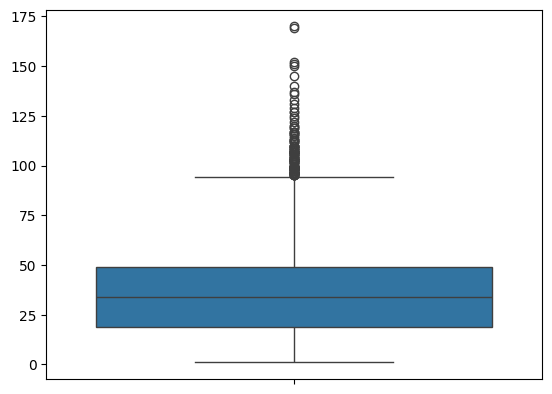

In [35]:
lengths = [len(sent) for sent in X_train_seq]
sns.boxplot(lengths)

In [36]:
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

In [37]:
from tensorflow.keras.layers import Input, Embedding, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Concatenate
vocab_size = len(tokenizer.word_index)+1
embedding_dim = 100
max_len = 100
embedding_layer = Embedding(input_dim=vocab_size,output_dim=embedding_dim,input_length=max_len,trainable=True)
text_input = Input(shape=(max_len,))
embedded = embedding_layer(text_input)
lstm_out = Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3))(embedded)
encoder_model = Model(inputs=text_input, outputs=lstm_out)

In [38]:
#Architecture for numeric model
num_input = Input(shape=(X_train_num.shape[1],))
num_dense = Dense(32, activation="relu")(num_input)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping
num_classes=len(le.classes_)
merged = Concatenate()([lstm_out, num_dense])
merged = Dense(64, activation="relu")(merged)
merged = Dropout(0.3)(merged)
output = Dense(num_classes, activation="softmax")(merged)

model = Model(inputs=[text_input, num_input], outputs=output)
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
earlystop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
history = model.fit(
    [X_train_pad, X_train_num],
    y_train,
    validation_data=([X_val_pad, X_val_num], y_val),
    epochs=25,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[earlystop]
)

Epoch 1/25
354/354 ━━━━━━━━━━━━━━━━━━━━ 170s 469ms/step - accuracy: 0.3875 - loss: 1.2226 - val_accuracy: 0.3861 - val_loss: 1.6296
Epoch 2/25
354/354 ━━━━━━━━━━━━━━━━━━━━ 171s 482ms/step - accuracy: 0.4461 - loss: 0.9965 - val_accuracy: 0.4126 - val_loss: 1.6282
Epoch 3/25
354/354 ━━━━━━━━━━━━━━━━━━━━ 189s 535ms/step - accuracy: 0.4777 - loss: 0.9204 - val_accuracy: 0.4122 - val_loss: 1.5773
Epoch 4/25
354/354 ━━━━━━━━━━━━━━━━━━━━ 187s 529ms/step - accuracy: 0.4954 - loss: 0.8718 - val_accuracy: 0.4165 - val_loss: 1.5911
Epoch 5/25
354/354 ━━━━━━━━━━━━━━━━━━━━ 181s 471ms/step - accuracy: 0.5146 - loss: 0.8377 - val_accuracy: 0.4374 - val_loss: 1.5701
Epoch 6/25
354/354 ━━━━━━━━━━━━━━━━━━━━ 169s 476ms/step - accuracy: 0.5308 - loss: 0.7836 - val_accuracy: 0.4597 - val_loss: 1.5569
Epoch 7/25
354/354 ━━━━━━━━━━━━━━━━━━━━ 176s 497ms/step - accuracy: 0.5488 - loss: 0.7697 - val_accuracy: 0.4618 - val_loss: 1.5842
Epoch 8/25
354/354 ━━━━━━━━━━━━━━━━━━━━ 160s 453ms/step - accuracy: 0.5667 -

In [42]:
preds = model.predict([X_test_pad, X_val_num])
predicted_labels = le.inverse_transform(preds.argmax(axis=1))

89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step


In [43]:
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = predicted_labels[:len(y_test_labels)]
from sklearn.metrics import classification_report
print("Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print("Precision:",precision_score(y_test_labels,y_pred_labels,average='macro'))
print("Recall:",recall_score(y_test_labels,y_pred_labels,average='macro'))
print("F1_score:",f1_score(y_test_labels,y_pred_labels,average='macro'))
print(classification_report(y_test_labels, y_pred_labels))

Accuracy: 0.4713375796178344
Precision: 0.46385081605895817
Recall: 0.5560940793326401
F1_score: 0.488021431870507
                                 precision    recall  f1-score   support

           Billing and Payments       0.76      0.76      0.76       298
               Customer Service       0.44      0.41      0.42       407
                General Inquiry       0.24      0.69      0.36        29
                Human Resources       0.56      0.55      0.55        55
                     IT Support       0.36      0.52      0.43       336
                Product Support       0.43      0.47      0.45       536
          Returns and Exchanges       0.36      0.58      0.44       139
            Sales and Pre-Sales       0.34      0.53      0.42        79
Service Outages and Maintenance       0.57      0.74      0.65       104
              Technical Support       0.57      0.31      0.40       843

                       accuracy                           0.47      2826
       

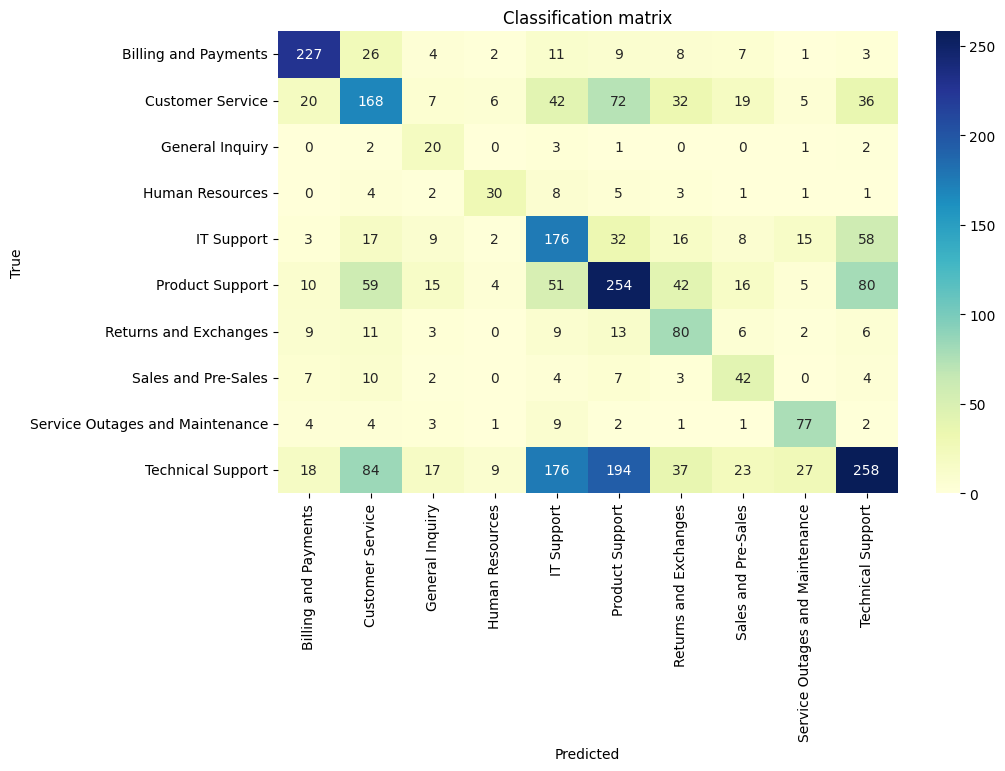

In [47]:
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,cmap="YlGnBu", xticklabels=le.classes_, yticklabels=le.classes_,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Classification matrix")
plt.show()

In [46]:
model.save("ticket_classifier.h5")
model.save("ticket_classifier.keras")
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
import joblib
joblib.dump(scaler, "scaler.pkl")
with open("le.pkl", "wb") as f:
    pickle.dump(le, f)

In [ ]:
#############################################################################End##########################################################################################

In [ ]:
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DistilBertTokenizerFast
tokenizer0 = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

In [167]:
X_train, X_temp1, y_train, y_temp1 = train_test_split(data1['body'], y, test_size=0.2)
X_val, X_test, y_val, y_test = train_test_split(X_temp1, y_temp1, test_size=0.2)

In [168]:
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(X_val),truncation=True,padding=True,max_length=128)
test_encodings = tokenizer(list(X_test),truncation=True,padding=True,max_length=128)

In [170]:
#Convert to tensors
import tensorflow as tf
X_train_ids  = tf.constant(train_encodings["input_ids"])
X_train_mask = tf.constant(train_encodings["attention_mask"])
X_val_ids    = tf.constant(val_encodings["input_ids"])
X_val_mask   = tf.constant(val_encodings["attention_mask"])
X_test_ids    = tf.constant(test_encodings["input_ids"])
X_test_mask   = tf.constant(test_encodings["attention_mask"])

In [171]:
train_dataset = tf.data.Dataset.from_tensor_slices(({"input_ids": X_train_ids, "attention_mask": X_train_mask}, y_train)).batch(32)
val_dataset   = tf.data.Dataset.from_tensor_slices(({"input_ids": X_val_ids, "attention_mask": X_val_mask}, y_val)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices(({"input_ids": X_test_ids, "attention_mask": X_test_mask}, y_test)).batch(32)

In [175]:
from transformers import TFDistilBertForSequenceClassification
model = TFDistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=len(le.classes_))

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [178]:
import tf_keras
optimizer = tf_keras.optimizers.Adam(learning_rate=5e-5)
loss_fn   = tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=3)

Epoch 1/3


707/707 [==============================] - 6210s 9s/step - loss: 1.6783 - accuracy: 0.3874 - val_loss: 1.5449 - val_accuracy: 0.4448
Epoch 2/3
 76/707 [==>...........................] - ETA: 2:07:41 - loss: 1.5790 - accuracy: 0.4062

In [ ]:
results = model.evaluate(test_dataset)
print("Test loss:", results[0])
print("Test accuracy:", results[1])

In [ ]:
# 10. Predict on new text
sample_text = ["System is down, please fix urgently"]
sample_enc = tokenizer(sample_text, truncation=True, padding=True, max_length=128, return_tensors="tf")

pred_logits = model.predict(sample_enc).logits
pred_class  = tf.argmax(pred_logits, axis=1).numpy()
print("Predicted label:", le.inverse_transform(pred_class))